In [1]:
import csv
import time
import matplotlib.pyplot as plt
import numpy as np
import re
from z3 import *
import hashlib
import random

In [2]:
def dec_to_bin(n: str):
    res = ''
    while n > 0:
        res = str(n % 2) + res
        n //= 2
    return res

In [3]:
def bin_to_dec(n: str):
    sum = 0
    for i, j in enumerate(n[::-1]):
        sum += int(j) * 2**i 
    return sum

In [4]:
### NE SERT A RIEN EN FAITE ###

def optimal_k(z: int) -> int:
    k = 1
    while True:
        borne_bin = "1" * (k - 1) + "0" * k + "1"
        borne_int = int(borne_bin, 2)
        
        # Si z est inférieur ou égal à la borne, on a trouvé le k optimal
        if z <= borne_int: 
            return k
        
        k += 1


In [5]:
z_bin = dec_to_bin(49)
z_int = bin_to_dec(z_bin)
k = optimal_k(z_int)
print(z_bin, z_int, k)

110001 49 3


In [6]:
class TseytinTransformation:
    
    def __init__(self):
        self.i = 0  
        self.sat = ""   
        self.dimacs = ""
        
        
        
    def AND(self, A: str, B: str) -> str:
        gate = f"gate{self.i}"
        res = f"(¬{A} + ¬{B} + {gate}) * ({A} + ¬{gate}) * ({B} + ¬{gate})"
        self.i += 1 
        return res
    
    
    
    def OR(self, A: str, B: str) -> str:
        gate = f"gate{self.i}"
        res = f"({A} + {B} + ¬{gate}) * (¬{A} + {gate}) * (¬{B} + {gate})"
        self.i += 1 
        return res
    
    
    
    def XOR(self, A: str, B: str) -> str:
        gate = f"gate{self.i}"
        res = f"(¬{A} + ¬{B} + ¬{gate}) * ({A} + {B} + ¬{gate}) * ({A} + ¬{B} + {gate}) * (¬{A} + {B} + {gate})"
        self.i += 1 
        return res
    
    
    
    def half_ADD(self, A: str, B: str) -> str:
        m1 = self.XOR(A, B)
        g1 = f"gate{self.i-1}"
        m2 = self.AND(A, B)
        g2 = f"gate{self.i-1}"
        
        res = m1 + " * " + m2
        
        return (res, g1, g2)
    
    
    
    def full_ADD(self, A: str, B: str, c_in: str) -> str:
        m1 = self.XOR(A, B)
        g1 = f"gate{self.i-1}"
        m2 = self.XOR(g1, c_in)
        g2 = f"gate{self.i-1}" #correspond à la sortie z de l'additionneur
        m3 = self.AND(g1, c_in)
        g3 = f"gate{self.i-1}"
        m4 = self.AND(A, B)
        g4 = f"gate{self.i-1}"
        m5 = self.OR(g3, g4)
        g5 = f"gate{self.i-1}"
        
        res = m1 + " * " + m2 + " * " + m3 + " * " + m4 + " * " + m5 

        return (res, g2, g5)
    
    
    
    def MULT(self, size_x: int, size_y: int) -> str:
        """
        Ajoute à la variable 'sat' la formule SAT correspondant à x * y = z

        Args:
            size_x, size_y (int):
                taille des entrées x et y en bits 
                
        """
        
        X, Y = [f"x{i}" for i in range(size_x)], [f"y{i}" for i in range(size_y)]
        self.i += size_x + size_y
        Z = []
        
        self.sat += self.AND(X[0], Y[0]) # "étage 0": première multiplication dont on récupère directement le résultat en sortie
        
        for i in range(size_y-1): # longueur des facteurs moins 1, correspond à l'indice des B
            for j in range(size_x): # correspond à l'indice des A
                if i == 0: # 1ère étage
                    if j < size_x - 1:
                        m1 = self.AND(X[j+1], Y[i])
                        g1 =  f"gate{self.i-1}"
                        m2 = self.AND(X[j], Y[i+1])
                        g2 = f"gate{self.i-1}"
                        
                        res, n, c_out = self.half_ADD(g1, g2) if j == 0 else self.full_ADD(g1, g2, c_out)
                        Z.append(n)
                        
                        self.sat += " * " + m1 + " * " + m2 + " * " + res
                        
                    else:
                        m = self.AND(X[j], Y[i+1])
                        g = f"gate{self.i-1}"
                        
                        res, n, c_out = self.half_ADD(c_out, g)
                        Z.append(n)
                        Z.append(c_out)
                        
                        self.sat += " * " + m + " * " + res
                        
                else:
                    
                    m = self.AND(X[j], Y[i+1])
                    g =  f"gate{self.i-1}"
                    res, n, c_out = self.half_ADD(Z[j], g) if j == 0 else self.full_ADD(Z[j], g, c_out)
                    Z[j] = n 
                    if j == size_x - 1:
                        Z.append(c_out)
                    
                    self.sat += " * " + m + " * " + res 
                    
            Z.pop(0) #permet de supprimer le resultat qui sera la sortie et donc plus nécessaire pour la suite des calculs
                
                
                
    @staticmethod
    def simplification_unit_clause(clauses):
        modified = True

        while modified:
            modified = False
            unit_clauses = [list(c)[0] for c in clauses if len(c) == 1] # récupérer chaque littéral

            for var in unit_clauses:
                neg = "-" + var if not var.startswith("-") else var[1:]

                new_clauses = []
                for clause in clauses:
                    if var in clause: # Clause satisfaite, on la retire
                        modified = True
                        continue
                    if neg in clause: # On supprime la variable négative de la clause
                        new_clause = clause.copy()
                        new_clause.discard(neg)
                        new_clauses.append(new_clause)
                        modified = True
                    else:
                        new_clauses.append(clause)

                clauses = new_clauses

        return clauses


    @staticmethod
    def simplifier_one(cnf_list: list[str]) -> list[set]:
        """Supprime les clauses subsumées par d'autres dans la liste CNF."""
        cnf_list = [clause for clause in cnf_list if not any(other < clause for other in cnf_list)]
        return cnf_list
        

    @staticmethod
    def simplifier_two(cnf_list: list[set]) -> list[set]:
        for i in range(len(cnf_list) - 1):
            for j in range(i + 1, len(cnf_list)):
                clause_i = cnf_list[i]
                clause_j = cnf_list[j]
                if len(clause_i) == 2 and len(clause_j) == 3:
                    for lit in clause_j:
                        if lit.startswith("-"): 
                            tmp_clause = clause_j - {lit}
                            tmp_clause.add(lit[1:])
                            if clause_i < tmp_clause:
                                cnf_list[j] = clause_j - {lit}
                                break
                elif len(clause_i) == 3 and len(clause_j) == 2:
                    for lit in clause_i:
                        if lit.startswith("-"):
                            tmp_clause = clause_i - {lit}
                            tmp_clause.add(lit[1:])
                            if clause_j < tmp_clause:
                                cnf_list[i] = clause_i - {lit}
                                break
        return cnf_list
        
    @staticmethod  
    def simplifier_three(cnf_list: list[set]) -> list[set]:
        for i in range(len(cnf_list) - 1):
            for j in range(i + 1, len(cnf_list)):
                if len(cnf_list[i]) == 2 and len(cnf_list[j]) == 2:
                    (liti1, liti2) = cnf_list[i]
                    if (liti1[1:] in cnf_list[j] and "-" + liti2 in cnf_list[j]) or ("-" + liti1 in cnf_list[j] and liti2[1:] in cnf_list[j]):
                        pure_liti1 = liti1[1:] if liti1.startswith("-") else liti1
                        pure_liti2 = liti2[1:] if liti2.startswith("-") else liti2
                        new_cnf = []
                        for clause in cnf_list:
                            if pure_liti2 in clause or "-" + pure_liti2 in clause:
                                if clause != cnf_list[i] and clause != cnf_list[j]:
                                    new_clause = set()
                                    for lit in clause:
                                        if lit == pure_liti2:
                                            new_clause.add(pure_liti1)
                                        elif lit == "-" + pure_liti2:
                                            new_clause.add("-" + pure_liti1)
                                        else:
                                            new_clause.add(lit)
                                    clause = new_clause
                            new_cnf.append(clause)
                        cnf_list = new_cnf         
        return cnf_list
                

    @staticmethod
    def normalize(lines):
        return set(frozenset(s) for s in lines)


    def simplify_cnf(dimacs_file: str, partial_resolution: bool=True):
        """Applique toutes les simplifications sur une CNF en format dimacs"""
        with open(dimacs_file, "r") as f:
            lines = f.readlines()
            
        lines_set = []
        for line in lines:
            if not line.startswith('p cnf'):
                lits = line.strip().split()
                lits.remove("0")
                lines_set.append(set(lits))
        
        previous = None
        while True:
            if partial_resolution:
                lines_set = TseytinTransformation.simplification_unit_clause(lines_set)
            lines_set = TseytinTransformation.simplifier_one(lines_set)
            lines_set = TseytinTransformation.simplifier_two(lines_set)
            lines_set = TseytinTransformation.simplifier_three(lines_set)

            normalized = TseytinTransformation.normalize(lines_set) # évite de faire des deepcopy pour comparer les s1, s2, s3
            if normalized == previous: # ça veut dire qu'il y a pas eu de simplification 
                break
            previous = normalized

        num_vars = len(set(var.lstrip('-') for clause in lines_set for var in clause))
        num_clauses = len(lines_set)
        
        try:
            with open(dimacs_file, 'x') as f:
                f.write(f"p cnf {num_vars} {num_clauses}\n")
                for clause in lines_set:
                    line = " ".join(map(str, clause)) + " 0\n"
                    f.write(line)
        except FileExistsError:
            with open(dimacs_file, 'w') as f:
                f.write(f"p cnf {num_vars} {num_clauses}\n")
                for clause in lines_set:
                    line = " ".join(map(str, clause)) + " 0\n"
                    f.write(line)
        
        

    @staticmethod
    def parse_formula(cnf_str: str, output_file: str, simplifie: bool = True):
        var_map = {}
        var_counter = 1
        clauses = []
        cnf_str = cnf_str.replace(" ", "") 
        cnf_str = cnf_str.split("*") 
        for clause in cnf_str:
            literals = re.findall(r"¬?\w+", clause) 
            clauses.append(list(literals))
        clauses_list = []
        for literals in clauses:
            clause = []
            for lit in literals:
                is_neg = False
                if lit.startswith("¬"): # gérer la négation
                    is_neg = True
                    lit = lit.strip("¬")
                if lit not in var_map: 
                    var_map[lit] = var_counter
                    var_counter += 1
                var_num = var_map[lit]
                clause.append("-" + str(var_num) if is_neg else str(var_num))
            clauses_list.append(set(clause))
            
        num_vars = len(var_map)
        num_clauses = len(clauses_list)
        
        try:
            with open(output_file, 'x') as f:
                f.write(f"p cnf {num_vars} {num_clauses}\n")
                for clause in clauses_list:
                    line = " ".join(map(str, clause)) + " 0\n"
                    f.write(line)
        except FileExistsError:
            with open(output_file, 'w') as f:
                f.write(f"p cnf {num_vars} {num_clauses}\n")
                for clause in clauses_list:
                    line = " ".join(map(str, clause)) + " 0\n"
                    f.write(line)
            
        return var_map
    
    
    @staticmethod
    def get_input_gate(var_dict):
        x_vars = []
        y_vars = []

        for key, value in var_dict.items():
            if key.startswith("x"):
                x_vars.append(value)
            elif key.startswith("y"):
                y_vars.append(value)

        return sorted(x_vars), sorted(y_vars)          
                
                    
                    
    @staticmethod          
    def get_output_gate(size_x: int, size_y: int) -> list:
        """
        Trouve le numéro des variables correspondant à la sortie dans la formule sous forme DIMACS

        Args:
            size_x, size_y (int):
                taille des entrées x et y en bits 
                
        """
        
        
        outputs = []
        gate = 0
        smaller, bigger = (size_x, size_y) if size_x < size_y else (size_y, size_x)
        
        for i in range(smaller):
            
            if i == 0:
                gate += 3                       # 2 portes A0 et B0 + AND
                outputs.append(gate)
            
            elif i == 1:
                gate += 2 + 2 + 1                       # 2 portes: une A1 et B1 + 2*AND + 1ère porte HADD
                outputs.append(gate)
                gate += 1                               # 2ème porte HADD
                gate += (1 + 2 + 5) * (bigger - 2)      # [porte Ai + 2*AND + ADD] k-2 fois
                gate += 1 + 2                           # porte B + HADD
                
            elif i > 1 and i != smaller-1:
                gate += 1 + 1 + 1                       # porte Bi + AND + 1ère porte HADD
                outputs.append(gate)
                gate += 1                               # 2ème porte HADD
                gate += (1 + 5) * (bigger - 1)          # [AND + ADD] * k-1 fois
                
            else:
                gate += 1 + 1 + 1               # porte Bi + AND + 1ère porte HADD
                outputs.append(gate)
                gate += 1                       # 2ème porte HADD
                for _ in range(bigger - 1):
                    gate += 1 + 2               # AND + 2 premières porte du ADD
                    outputs.append(gate)
                    gate += 3                   # 3 dernières portes 
                outputs.append(gate)        
        
        return outputs
    
    
    
    @staticmethod
    def add_z_to_dimacs(z_bin: int, size_x: int, size_y: int, dimacs_file: str): 
        """
        Ajoute au fichier DIMACS la valeur des variables qui correspondent à la sortie z

        Args:
            z (int): 
                résultat en binaire de la multiplication x * y = z
            k (int):
                taille des entrées x et y en bits 
            dimacs_file (str):
                nom du fichier où se trouve la formule SAT en format DIMACS
                
        """
        
        z_var = TseytinTransformation.get_output_gate(size_x, size_y)
        
        while len(z_bin) != len (z_var):
            z_bin = "0" + z_bin
            
        with open(dimacs_file, "a") as f:
            for zi_bin, zi_var in zip(z_bin[::-1], z_var):
                f.write(f"{str(zi_var)} 0\n") if zi_bin == "1" else f.write(f"-{str(zi_var)} 0\n")
        
        with open(dimacs_file, "r") as f:
                lines = f.readlines()  # Lire toutes les lignes

        # Modifier la première ligne car on a ajouté des variables
        if lines[0].startswith("p cnf"):
            parts = lines[0].split()
            num_vars = parts[2]  # Récupérer le nombre de variables
            num_clauses = int(parts[3]) + len(z_var)  # Ajouter les nouvelles clauses
            lines[0] = f"p cnf {num_vars} {num_clauses}\n"  # Mettre à jour la ligne

        # Réécrire le fichier avec la ligne modifiée
        with open(dimacs_file, "w") as f:
            f.writelines(lines)

In [7]:
def SAT_producer(x: int, y: int, simplifie: bool = True, partial_resolution: bool = False, bloat: bool = False, repository: str = "../data/dimacs"):
    
    if y > x:
        tmp = x
        x = y
        y = tmp
        
    z = x * y
    x_bin = dec_to_bin(x)
    y_bin = dec_to_bin(y)
    z_bin = dec_to_bin(z)
    
    if bloat:
        x_bin = len(x_bin) * "0" + x_bin
        y_bin = len(y_bin) * "0" + y_bin
        
    size_x = len(x_bin)
    size_y = len(y_bin)

    if simplifie:
        if partial_resolution:
            filename = f"{repository}/{size_x}x{size_y}_{hashlib.sha256((str(x) + str(y)).encode()).hexdigest()[:4]}_simplified+resolved.dimacs"
        else:
            filename = f"{repository}/{size_x}x{size_y}_{hashlib.sha256((str(x) + str(y)).encode()).hexdigest()[:4]}_simplified.dimacs"
    else:
        filename = f"{repository}/{size_x}x{size_y}_{hashlib.sha256((str(x) + str(y)).encode()).hexdigest()[:4]}.dimacs"
    
    ts_transform = TseytinTransformation()
    ts_transform.MULT(size_x, size_y)
    ts_transform.dimacs = filename
    
    vars_map = TseytinTransformation.parse_formula(ts_transform.sat, ts_transform.dimacs, simplifie)
    TseytinTransformation.add_z_to_dimacs(z_bin, size_x, size_y, ts_transform.dimacs)

    x_vars, y_vars = TseytinTransformation.get_input_gate(vars_map)
    z_vars = TseytinTransformation.get_output_gate(size_x, size_y)
    
    if simplifie:
        if partial_resolution:
            TseytinTransformation.simplify_cnf(ts_transform.dimacs, True)
        else:
            TseytinTransformation.simplify_cnf(ts_transform.dimacs, False)
    
    return ts_transform, x_vars, y_vars, z_vars


In [8]:
def get_varClause(filepath: str):
    """ Extraire nb variables et clauses """
    with open(filepath, 'r') as f:
        for line in f:
            if line.startswith('p cnf'):
                _, _, vars_, clauses = line.strip().split()
                return int(vars_), int(clauses)
            

def count_clause_sizes_in_dimacs(dimacs_file: str) -> tuple[int, int, int]:
    """ Compte le nombre de clauses de 1, 2 et 3 variables dans un fichier DIMACS. """
    nb_1var = 0
    nb_2var = 0
    nb_3var = 0

    with open(dimacs_file, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("p") or line.startswith("c") or not line:
                continue 

            literals = line.split()[:-1]  # on enlève le 0 de fin de clause

            if len(literals) == 1:
                nb_1var += 1
            elif len(literals) == 2:
                nb_2var += 1
            elif len(literals) == 3:
                nb_3var += 1

    return nb_1var, nb_2var, nb_3var


In [40]:
# Tests

x = 1000000000039
y = 1000000000061
x = 16453
y = 16477
x = 29
y = 31

satFormula, x_vars, y_vars, z_vars = SAT_producer(x, y, simplifie=False)
print(x_vars, y_vars, z_vars)
print(satFormula.sat)
print(satFormula.dimacs)
print(count_clause_sizes_in_dimacs(satFormula.dimacs))

[1, 4, 10, 18, 26] [2, 6, 37, 65, 93] [3, 8, 39, 67, 95, 99, 105, 111, 117, 120]
(¬x0 + ¬y0 + gate10) * (x0 + ¬gate10) * (y0 + ¬gate10) * (¬x1 + ¬y0 + gate11) * (x1 + ¬gate11) * (y0 + ¬gate11) * (¬x0 + ¬y1 + gate12) * (x0 + ¬gate12) * (y1 + ¬gate12) * (¬gate11 + ¬gate12 + ¬gate13) * (gate11 + gate12 + ¬gate13) * (gate11 + ¬gate12 + gate13) * (¬gate11 + gate12 + gate13) * (¬gate11 + ¬gate12 + gate14) * (gate11 + ¬gate14) * (gate12 + ¬gate14) * (¬x2 + ¬y0 + gate15) * (x2 + ¬gate15) * (y0 + ¬gate15) * (¬x1 + ¬y1 + gate16) * (x1 + ¬gate16) * (y1 + ¬gate16) * (¬gate15 + ¬gate16 + ¬gate17) * (gate15 + gate16 + ¬gate17) * (gate15 + ¬gate16 + gate17) * (¬gate15 + gate16 + gate17) * (¬gate17 + ¬gate14 + ¬gate18) * (gate17 + gate14 + ¬gate18) * (gate17 + ¬gate14 + gate18) * (¬gate17 + gate14 + gate18) * (¬gate17 + ¬gate14 + gate19) * (gate17 + ¬gate19) * (gate14 + ¬gate19) * (¬gate15 + ¬gate16 + gate20) * (gate15 + ¬gate20) * (gate16 + ¬gate20) * (gate19 + gate20 + ¬gate21) * (¬gate19 + gate21) 

In [10]:
satFormula, x_vars, y_vars, z_vars = SAT_producer(x, y, simplifie=True, partial_resolution=False)
print(count_clause_sizes_in_dimacs(satFormula.dimacs))

(30, 1650, 2387)


In [50]:
satFormula, x_vars, y_vars, z_vars = SAT_producer(x, y, simplifie=True, partial_resolution=True)
print(count_clause_sizes_in_dimacs(satFormula.dimacs))

(0, 1721, 2272)


In [41]:
solver = Solver()
solver.from_file(satFormula.dimacs)
solver.check()
stat = solver.statistics()
print(stat)

(:max-memory            20.28
 :memory                17.61
 :num-allocs            15479383
 :rlimit-count          2710281
 :sat-decisions         7
 :sat-mk-clause-2ary    163
 :sat-mk-clause-nary    173
 :sat-mk-var            122
 :sat-propagations-2ary 54
 :sat-propagations-nary 48
 :sat-units             12
 :time                  0.00)


In [39]:
stat.get_key_value('sat backjumps')

3934

In [125]:
def flip_variable_in_dimacs(dimacs_file: str, var: int):
    
    flipped_lines = []
    with open(dimacs_file, "r") as f:
        lines = f.readlines()
        
    for line in lines:
        if line.startswith("p cnf") or line.startswith("c") or line.strip() == "":
            flipped_lines.append(line)
            continue

        literals = line.strip().split()
        new_literals = []
        for lit in literals:
            if lit == "0":
                new_literals.append("0")
            elif lit == f"{var}":
                new_literals.append(f"-{var}")
            elif lit == f"-{var}":
                new_literals.append(f"{var}")
            else:
                new_literals.append(lit)

        flipped_lines.append(" ".join(new_literals) + "\n")

    # Réécriture avec changement de variable dans un nouveau fichier
    base, ext = os.path.splitext(dimacs_file)
    new_dimacs_file = f"{base}_{var}_flip_all{ext}"
    with open(new_dimacs_file, "w") as f:
        f.writelines(flipped_lines)

    return new_dimacs_file

In [126]:
# 5 -5 -5 -5 5 5 -5 -5 5
new_dimacs = flip_variable_in_dimacs(satFormula.dimacs, 5)

In [127]:
def flip_one_occurrence_in_dimacs(dimacs_file: str, var: int):
    with open(dimacs_file, "r") as f:
        lines = f.readlines()

    occurrences = []
    for i, line in enumerate(lines):
        if line.startswith("p cnf") or line.startswith("c") or line.strip() == "":
            continue

        literals = line.strip().split()
        for j, lit in enumerate(literals):
            if lit == str(var) or lit == f"-{var}":
                occurrences.append((i, j))


    line_idx, lit_idx = random.choice(occurrences)

    lit = lines[line_idx].strip().split()
    lit[lit_idx] = str(-int(lit[lit_idx]))  
    lines[line_idx] = " ".join(lit) + "\n"

    base, ext = os.path.splitext(dimacs_file)
    new_file = f"{base}_{var}_1flip{ext}"
    with open(new_file, "w") as f:
        f.writelines(lines)

    return new_file


In [134]:
def flip_one_occurrence_in_dimacs2(dimacs_file: str, var: int) -> list[str]:
    with open(dimacs_file, "r") as f:
        original_lines = f.readlines()

    occurrences = []
    for i, line in enumerate(original_lines):
        if line.startswith("p cnf") or line.startswith("c") or line.strip() == "":
            continue

        literals = line.strip().split()
        for j, lit in enumerate(literals):
            if lit == f"{var}" or lit == f"-{var}":
                occurrences.append((i, j))

    new_dimacs_files = []
    for line_idx, lit_idx in occurrences:
        lines_copy = original_lines.copy()  

        lit = lines_copy[line_idx].strip().split()
        lit[lit_idx] = str(-int(lit[lit_idx]))  # inversion du signe
        lines_copy[line_idx] = " ".join(lit) + "\n"

        base, ext = os.path.splitext(dimacs_file)
        new_file = f"{base}_{var}-{line_idx}_1flip{ext}"
        with open(new_file, "w") as f:
            f.writelines(lines_copy)

        new_dimacs_files.append(new_file)

    return new_dimacs_files


In [ ]:
vars, _ = get_varClause(satFormula.dimacs)
solver = Solver()
statistics = {}
for var in range(1, vars + 1):
    new_dimacs = flip_one_occurrence_in_dimacs2(satFormula.dimacs, var)
    sat = 0
    unsat = 0
    for dimacs in new_dimacs:
        solver.from_file(dimacs)
        if solver.check() == sat:
            sat += 1
        else:
            unsat += 1

    statistics[var] = (sat / len(new_dimacs), unsat / len(new_dimacs)) # (SAT, UNSAT)
        

In [112]:
display(statistics)

{1: (0.0, 1.0),
 2: (0.0, 1.0),
 3: (0.0, 1.0),
 4: (0.0, 1.0),
 5: (0.0, 1.0),
 6: (0.0, 1.0),
 7: (0.0, 1.0),
 8: (0.0, 1.0),
 9: (0.0, 1.0),
 10: (0.0, 1.0),
 11: (0.0, 1.0),
 12: (0.0, 1.0),
 13: (0.0, 1.0),
 14: (0.0, 1.0),
 15: (0.0, 1.0),
 16: (0.0, 1.0),
 17: (0.0, 1.0),
 18: (0.0, 1.0),
 19: (0.0, 1.0),
 20: (0.0, 1.0),
 21: (0.0, 1.0),
 22: (0.0, 1.0),
 23: (0.0, 1.0),
 24: (0.0, 1.0),
 25: (0.0, 1.0),
 26: (0.0, 1.0),
 27: (0.0, 1.0),
 28: (0.0, 1.0),
 29: (0.0, 1.0),
 30: (0.0, 1.0),
 31: (0.0, 1.0),
 32: (0.0, 1.0),
 33: (0.0, 1.0),
 34: (0.0, 1.0),
 35: (0.0, 1.0),
 36: (0.0, 1.0),
 37: (0.0, 1.0),
 38: (0.0, 1.0),
 39: (0.0, 1.0),
 40: (0.0, 1.0),
 41: (0.0, 1.0),
 42: (0.0, 1.0),
 43: (0.0, 1.0),
 44: (0.0, 1.0),
 45: (0.0, 1.0),
 46: (0.0, 1.0),
 47: (0.0, 1.0),
 48: (0.0, 1.0),
 49: (0.0, 1.0),
 50: (0.0, 1.0),
 51: (0.0, 1.0),
 52: (0.0, 1.0),
 53: (0.0, 1.0),
 54: (0.0, 1.0),
 55: (0.0, 1.0),
 56: (0.0, 1.0),
 57: (0.0, 1.0),
 58: (0.0, 1.0),
 59: (0.0, 1.0),
 60: (

In [129]:
def solve(file: str, display: bool = False, x_vars: list = None, y_vars: list = None, z_vars: list = None):
    """ Résout la formule SAT décrit par le fichier 'file' qui esr en format dimacs avec z3 """
    if display:
        if None in (x_vars, y_vars, z_vars):
            raise ValueError("Quand 'display=True', vous devez spécifier 'x_vars', 'y_vars' et 'z_vars'")

    solver = Solver()
    solver.from_file(file)

    if solver.check() == sat:
        print("c'est sat")
        if display:
            model = solver.model()

            result = { "x": {}, "y": {}, "z": {} }
            
            for d in model.decls():
                var_num = int(d.name()[2:])  # Suppression du préfixe ζ et conversion en int
                
                if var_num in x_vars:
                    result["x"][var_num] = model[d]
                elif var_num in y_vars:
                    result["y"][var_num] = model[d]
                elif var_num in z_vars:
                    result["z"][var_num] = model[d]

            # Construire les sorties binaires en utilisant join() 
            def binary_output(variable_results):
                return "".join("0" if not variable_results[k] else "1" for k in sorted(variable_results.keys(), reverse=True))

            x_output = binary_output(result["x"])
            y_output = binary_output(result["y"])
            z_output = binary_output(result["z"])
            
            x_output_dec = bin_to_dec(str(x_output))
            y_output_dec = bin_to_dec(str(y_output))
            z_output_dec = bin_to_dec(str(z_output))
            
            print(f"{x_output_dec} * {y_output_dec} = {z_output_dec}")
    else:
        print("Problème insatisfiable.")

In [133]:
file = f"{satFormula.dimacs}"
solve(file, True, x_vars, y_vars, z_vars)
n1 = flip_one_occurrence_in_dimacs(file, 5)
solve(n1, True, x_vars, y_vars, z_vars)
n2 = flip_one_occurrence_in_dimacs(file, 5)
solve(n1, True, x_vars, y_vars, z_vars)
n3 = flip_one_occurrence_in_dimacs(file, 5)
solve(n1, True, x_vars, y_vars, z_vars)
n4 = flip_one_occurrence_in_dimacs(file, 5)
solve(n1, True, x_vars, y_vars, z_vars)
n5 = flip_one_occurrence_in_dimacs(file, 5)
solve(n1, True, x_vars, y_vars, z_vars)
""" for dimacs in new_dimacs:
    solve(dimacs, True, x_vars, y_vars, z_vars) """

c'est sat
16477 * 16453 = 271096081
Problème insatisfiable.
c'est sat
16453 * 16477 = 271096081
c'est sat
16477 * 16453 = 271096081
c'est sat
16453 * 16477 = 271096081
c'est sat
16453 * 16477 = 271096081


' for dimacs in new_dimacs:\n    solve(dimacs, True, x_vars, y_vars, z_vars) '

In [53]:
TseytinTransformation.get_output_gate(3, 3)

[3, 8, 23, 27, 33, 36]

In [ ]:
from ..code.analysis.SATTools import *

def gen(primes_per_bits: dict, nb_mults: int = 10):
    
    for size_bits, primes in primes_per_bits.items():
        if len(primes) < 2 or size_bits < 5:
            print("Il y a un problème, pas normal")
            break
        pairs = generate_mult(primes, nb_mults)
        
        for x, y in pairs:
            ts, _, _, _ = SAT_producer(x, y, simplifie=False)
            dimacs_file = ts.dimacs
            nb_var, _ = get_varClause(dimacs_file)
            solver = Solver()
            solver.from_file(dimacs_file)
            t1 = time_to_solve(dimacs_file)
            random_var = random.randint(1, nb_var)
            with open(dimacs_file, 'w') as f:
                # écrire à la tout fin du fichier f"random_var 0"
            if solver.check() == "sat":
                t2 = time_to_solve
                
    return None

In [85]:
def time_evaluation(file: str):
    """ Evalue le temps que prend la résolution d'une formule SAT grâce à z3 """
    start_time = time.time()
    solve(file)
    finished_time = time.time() - start_time
        
    return finished_time

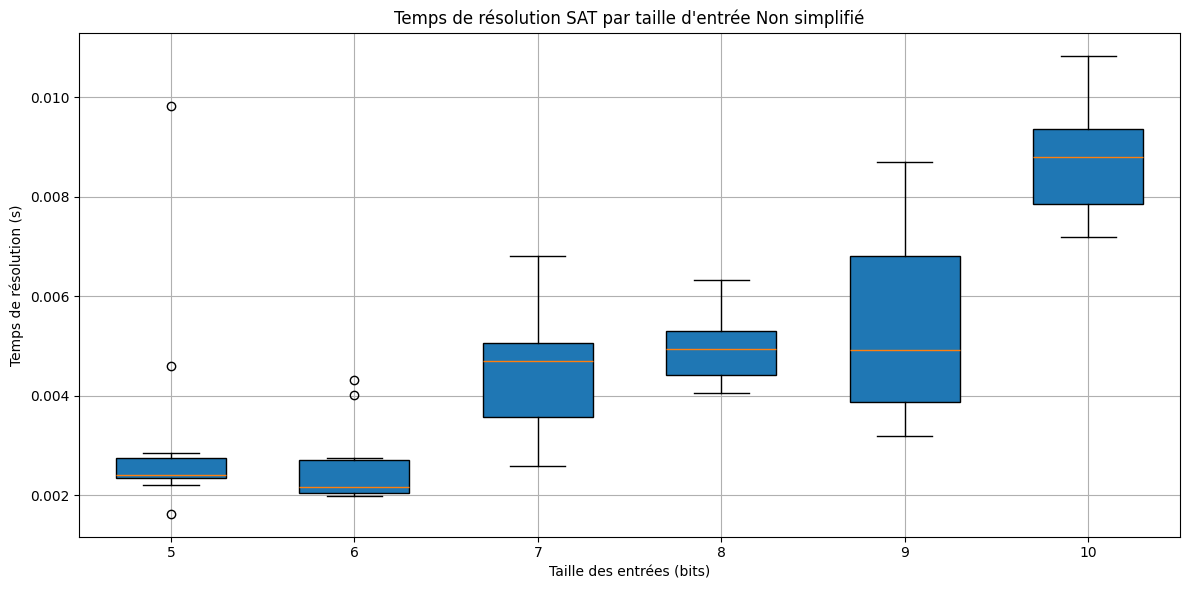

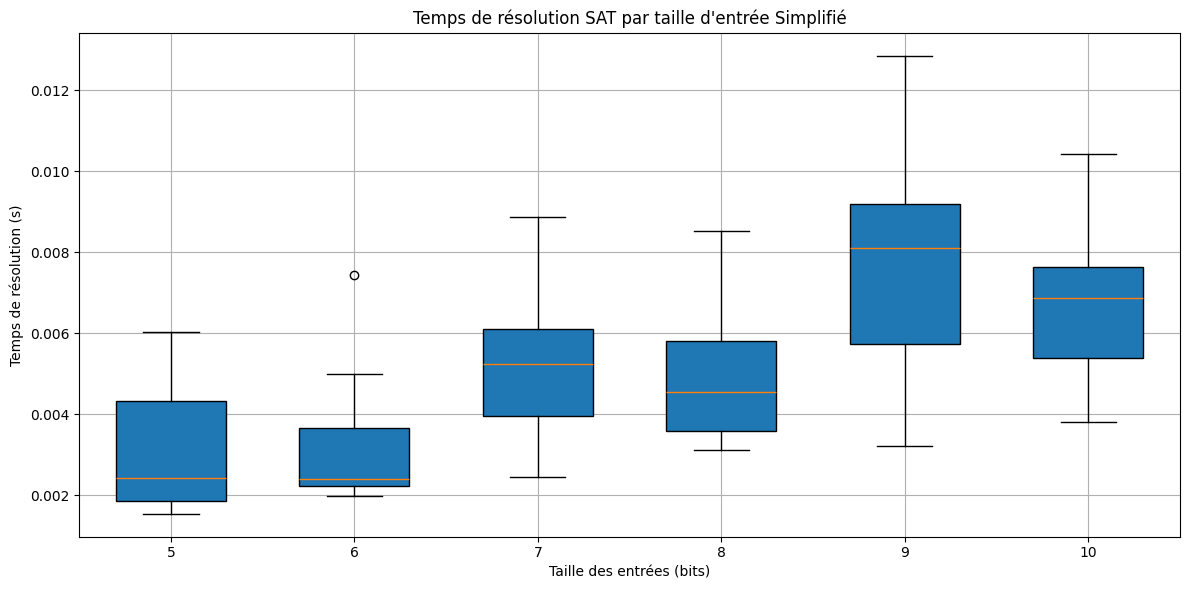

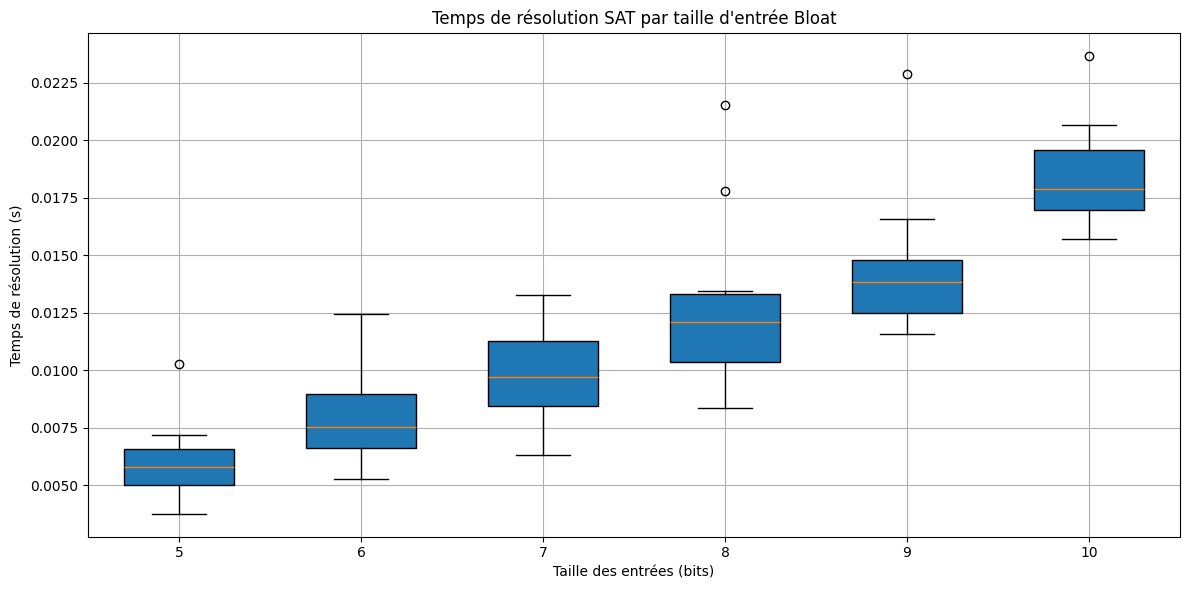

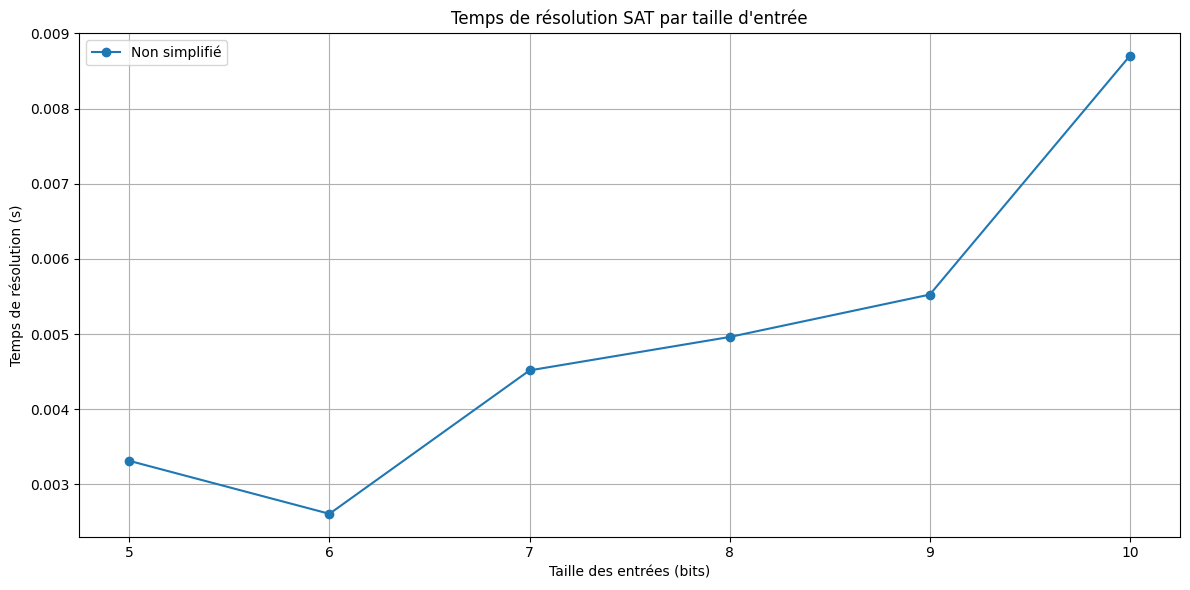

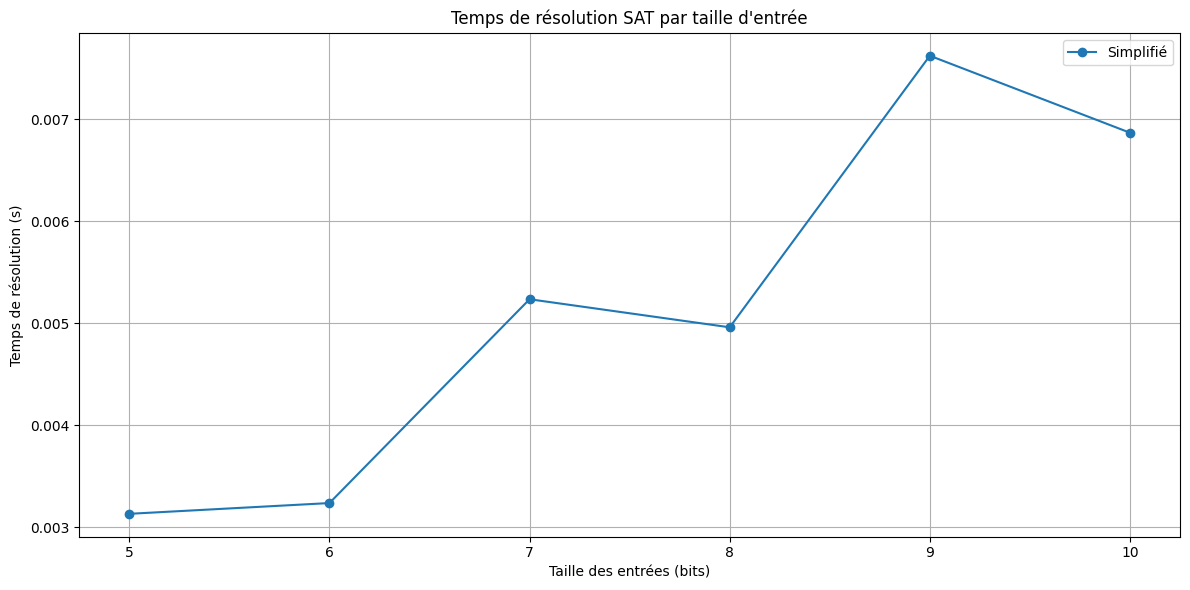

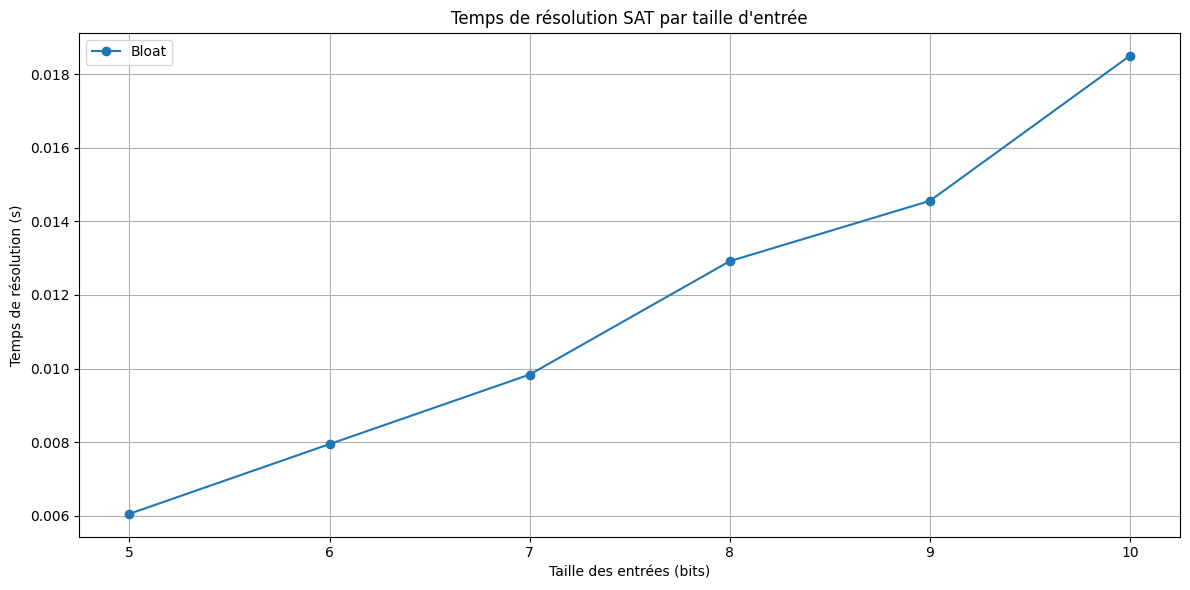

In [ ]:
def load_primes(csv_filename):
    primes_per_bits = {}
    with open(csv_filename, newline='') as csvfile:
        reader = csv.DictReader(csvfile)
        for row in reader:
            size = int(row["size_bits"])
            prime = int(row["prime"])
            if size not in primes_per_bits:
                primes_per_bits[size] = []
            primes_per_bits[size].append(prime)
    return primes_per_bits

def generate_mult(primes, count=10):
    mults = set()
    tries = 0
    while len(mults) < count and tries < 1000:
        x, y = random.sample(primes, 2)
        pair = tuple(sorted((x, y)))
        mults.add(pair)
        tries += 1
    return list(mults)

def evaluer_strategie(primes_per_bits, simplifie=False, bloat=False):
    time_per_bits = {}
    for size_bits, primes in primes_per_bits.items():
        if len(primes) < 2 or size_bits < 5:
            continue
        pairs = generate_mult(primes)
        times = []
        for x, y in pairs:
            ts, _, _, _ = SAT_producer(x, y, simplifie=simplifie, bloat=bloat)
            elapsed = time_evaluation("../../dimacsFiles/" + ts.dimacs)
            times.append(elapsed)
        time_per_bits[size_bits] = times
    return time_per_bits

def plot_boxplots(data_dict, label):
    plt.figure(figsize=(12, 6))
    keys = sorted(data_dict.keys())
    values = [data_dict[k] for k in keys]
    plt.boxplot(values, positions=keys, widths=0.6, patch_artist=True)
    
    plt.xlabel("Taille des entrées (bits)")
    plt.ylabel("Temps de résolution (s)")
    plt.title(f"Temps de résolution SAT par taille d'entrée {label}")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"../../graphiques/boxplot_{label}.png")

def plot_linearplot(data_dict, label):
    plt.figure(figsize=(12, 6))
    keys = sorted(data_dict.keys())
    values = [np.mean(data_dict[k]) for k in keys]  # Moyenne pour chaque clé

    plt.plot(keys, values, marker='o', label=label)
    plt.xlabel("Taille des entrées (bits)")
    plt.ylabel("Temps de résolution (s)")
    plt.title("Temps de résolution SAT par taille d'entrée")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"../../graphiques/linearplot_{label}.png")


csv_path = "../../utils/primes.csv"
premiers_par_bits = load_primes(csv_path)

non_simplifie = evaluer_strategie(premiers_par_bits, simplifie=False, bloat=False)

simplifie = evaluer_strategie(premiers_par_bits, simplifie=True, bloat=False)

bloat = evaluer_strategie(premiers_par_bits, simplifie=False, bloat=True)

plot_boxplots(non_simplifie, "Non simplifié") 
plot_boxplots(simplifie, "Simplifié") 
plot_boxplots(bloat, "Bloat") 

plot_linearplot(non_simplifie, "Non simplifié") 
plot_linearplot(simplifie, "Simplifié") 
plot_linearplot(bloat, "Bloat") 

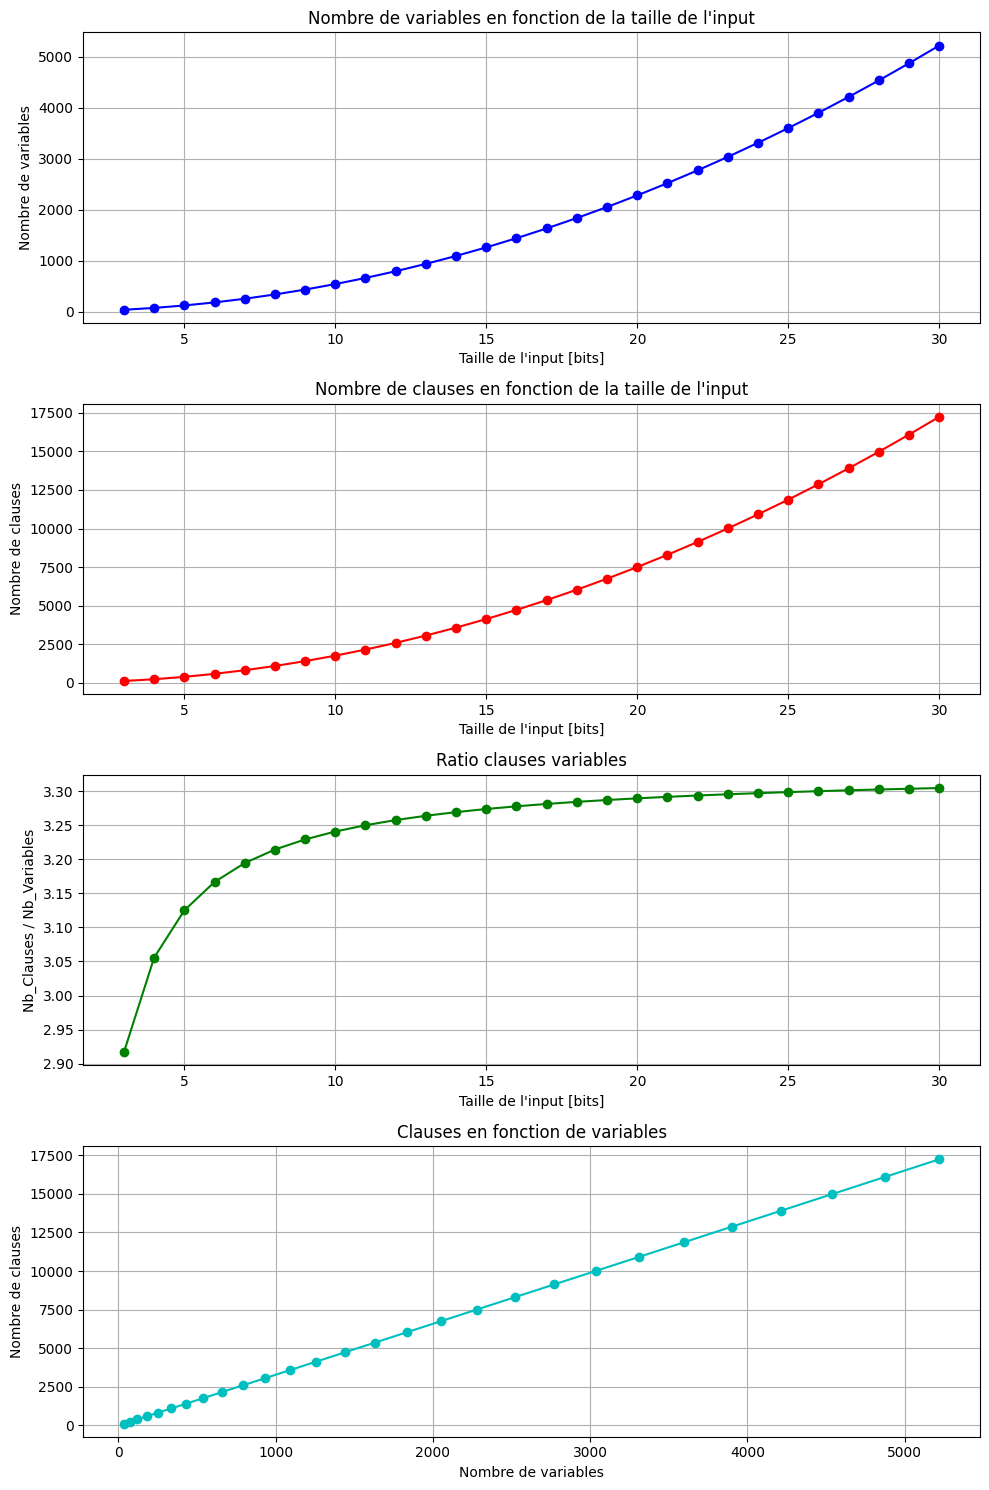

In [ ]:
folder_path = "../../grapheVarClauses"

size_inputs = list(range(3, 31))  # Tailles en bits de l'input (de 3 à 30)
nb_vars_list = []
nb_clauses_list = []

# Parcours des fichiers DIMACS
for size in size_inputs:
    file_path = folder_path + f"/{size}.dimacs"
    # Lire la première ligne du fichier
    try:
        with open(file_path, "r") as f:
            for line in f:
                if line.startswith("p cnf"):
                    _, _, nb_var, nb_clauses = line.split()
                    nb_vars_list.append(int(nb_var))
                    nb_clauses_list.append(int(nb_clauses))
                    break  # On arrête après avoir trouvé la ligne "p cnf" càd la 1ère ligne
    except FileExistsError:
        print("exost pas")

nb_clauses_per_var = [c / v for c, v in zip(nb_clauses_list, nb_vars_list)] # Calcul du rapport clauses/variables


fig, axs = plt.subplots(4, 1, figsize=(10, 15))

# Subplot 1 : Nombre de variables en fonction de la taille de l'input
axs[0].plot(size_inputs[:len(nb_vars_list)], nb_vars_list, marker="o", color="b")
axs[0].set_title("Nombre de variables en fonction de la taille de l'input")
axs[0].set_xlabel("Taille de l'input [bits]")
axs[0].set_ylabel("Nombre de variables")
axs[0].grid()

# Subplot 2 : Nombre de clauses en fonction de la taille de l'input
axs[1].plot(size_inputs[:len(nb_clauses_list)], nb_clauses_list, marker="o", color="r")
axs[1].set_title("Nombre de clauses en fonction de la taille de l'input")
axs[1].set_xlabel("Taille de l'input [bits]")
axs[1].set_ylabel("Nombre de clauses")
axs[1].grid()

# Subplot 3 : Rapport clauses/variables en fonction de la taille de l'input
axs[2].plot(size_inputs[:len(nb_clauses_per_var)], nb_clauses_per_var, marker="o", color="g")
axs[2].set_title("Ratio clauses variables")
axs[2].set_xlabel("Taille de l'input [bits]")
axs[2].set_ylabel("Nb_Clauses / Nb_Variables")
axs[2].grid()

axs[3].plot(nb_vars_list, nb_clauses_list, marker="o", color="c")
axs[3].set_title("Clauses en fonction de variables")
axs[3].set_xlabel("Nombre de variables")
axs[3].set_ylabel("Nombre de clauses")
axs[3].grid()

plt.tight_layout()
plt.show()

In [ ]:
def time_evaluation(csv_file: str, test: bool = False):
    results = []  # Stocker les résultats
    with open(csv_file, "r") as f:
        reader = csv.DictReader(f) 
        for row in reader:
            size_inputs = int(row["size_inputs"])
            x_prime = int(row["x_prime"])
            y_prime = int(row["y_prime"])
            x_vars = list(row["x_vars"])
            y_vars = list(row["y_vars"])
            z_vars = list(row["z_vars"])

            if size_inputs < 20:
                SAT_producer(x_prime, y_prime, test)

                start_time = time.time()
                #solve(f"../dimacsFiles/{size_inputs}.dimacs", x_vars, y_vars, z_vars)
                solver = Solver()
                solver.from_file(f"../dimacsFiles/{size_inputs}.dimacs")
                solver.check()
                finished_time = time.time() - start_time

                results.append(finished_time)
        
    return results

In [ ]:
res = time_evaluation("../../utils/info.csv")
res2 = time_evaluation("../../utils/info.csv", True)

[0.0036873817443847656, 0.00548863410949707, 0.006420135498046875, 0.003911733627319336, 0.003941774368286133, 0.007269620895385742, 0.010221242904663086, 0.011804342269897461, 0.023974180221557617, 0.03712129592895508, 0.024970293045043945, 0.07356142997741699, 0.0562281608581543, 0.5905923843383789, 3.331454277038574, 10.211929082870483, 14.992356061935425]
[0.006361722946166992, 0.0027627944946289062, 0.003905057907104492, 0.0031049251556396484, 0.004264116287231445, 0.005627155303955078, 0.008585214614868164, 0.01476144790649414, 0.022913217544555664, 0.038240671157836914, 0.027534961700439453, 0.08163213729858398, 0.08035922050476074, 0.69956374168396, 3.414510726928711, 10.561859369277954, 13.102908849716187]


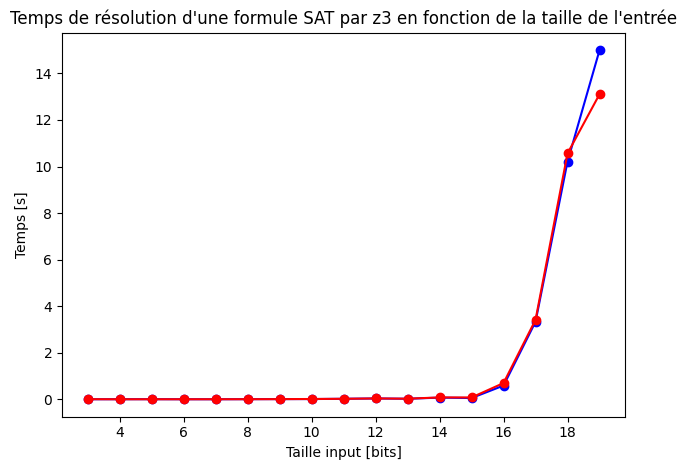

In [ ]:
size_inputs = np.arange(3, 20)
print(res)
print(res2)


res_np = np.array(res)
res2_np = np.array(res2)

plt.plot(size_inputs, res_np, marker="o", color="b")
plt.plot(size_inputs, res2_np, marker="o", color="r")
plt.title("Temps de résolution d'une formule SAT par z3 en fonction de la taille de l'entrée")
plt.xlabel("Taille input [bits]")
plt.ylabel("Temps [s]")

plt.tight_layout()
plt.show()

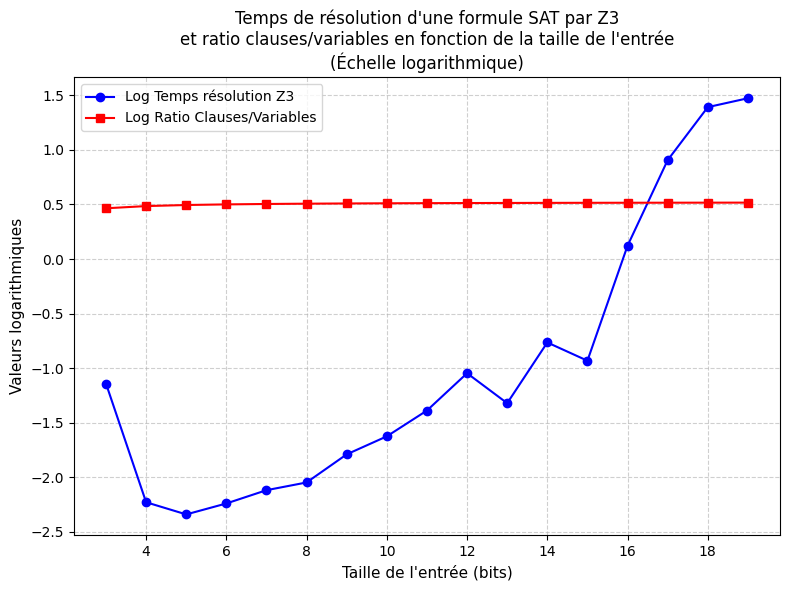

In [ ]:
nb_clauses_per_var_np = np.array(nb_clauses_per_var)

res_np_log = np.log10(res_np)
nb_clauses_per_var_np_log = np.log10(nb_clauses_per_var_np)

plt.figure(figsize=(8, 6)) 

plt.plot(size_inputs, res_np_log, marker="o", color="b", label="Log Temps résolution Z3")
plt.plot(size_inputs, nb_clauses_per_var_np_log[:len(size_inputs)], marker="s", color="r", label="Log Ratio Clauses/Variables")
plt.title("Temps de résolution d'une formule SAT par Z3\n"
          "et ratio clauses/variables en fonction de la taille de l'entrée\n"
          "(Échelle logarithmique)", fontsize=12)
plt.xlabel("Taille de l'entrée (bits)", fontsize=11)
plt.ylabel("Valeurs logarithmiques", fontsize=11)
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()